---------- New Run ----------


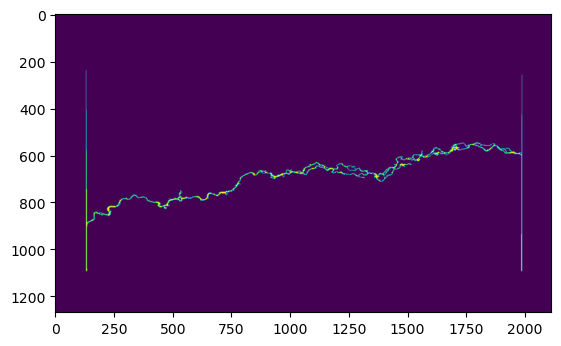

In [38]:
from rivgraph.classes import river
import matplotlib.pyplot as plt
import os

# Define the path to the georeferenced binary image.
mask_path = r"C:\Users\jon20\Documents\ArcGIS\Projects\CIVIC\trollfoot\l72000m.tif"

# Results will be saved with this name
name = 'kanektok'

# Where to store RivGraph-generated geotiff and geovector files.
results_folder = r"C:\Users\jon20\Documents\ArcGIS\Projects\CIVIC\trollresults"

# Set the exit sides of the river relative to the image. In this case, the
# Brahmaputra is "entering" the image from the North and "exiting" the
# image from the South.
es = 'EW' # The first character is the upstream side

# Boot up the river class! We set verbose=True to see progress of processing.
kanektok = river(name, mask_path, results_folder, exit_sides=es, verbose=True)

# The mask has been re-binarized and stored as an attribute of brahma:
plt.imshow(kanektok.Imask)

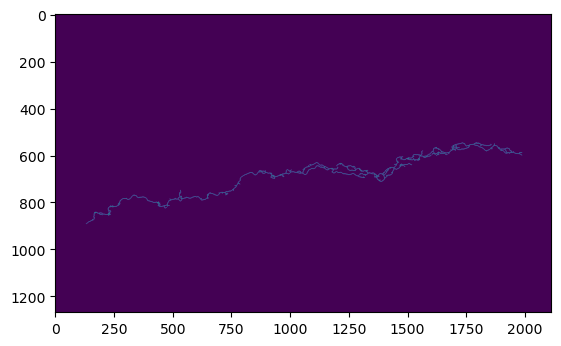

In [39]:
# Simply use the skeletonize() method.
kanektok.skeletonize()

# The skeletonized image is stored as an attribute to the brahm class. Let's take a look.
plt.imshow(kanektok.Iskel)

In [40]:
# We use the write_geotiff() method with the 'skeleton' option.
kanektok.to_geotiff('skeleton')

Geotiff written to C:\Users\jon20\Documents\ArcGIS\Projects\CIVIC\trollresults\kanektok_skel.tif.


In [41]:
# Simply use the compute_network() method.
kanektok.compute_network()

Resolving links and nodes...
links and nodes have been resolved.


In [42]:
# Now we can see that the "links" and "nodes" dictionaries ahve been added
# as attributes to the brahma class:
links = kanektok.links
nodes = kanektok.nodes
print('links: {}'.format(links.keys()))
print('nodes: {}'.format(nodes.keys()))

links: dict_keys(['idx', 'conn', 'id', 'n_networks'])
nodes: dict_keys(['idx', 'conn', 'id'])


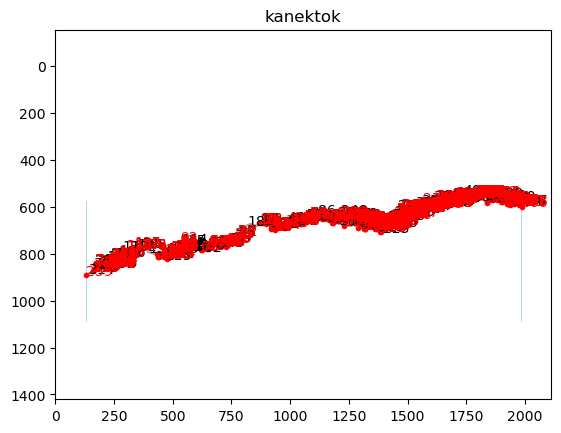

In [43]:
kanektok.plot('network')

In [44]:
kanektok.to_geovectors('network', ftype='json')

# Let's see where the network geovector files were written:
print(kanektok.paths['links'])
print(kanektok.paths['nodes'])

C:\Users\jon20\Documents\ArcGIS\Projects\CIVIC\trollresults\kanektok_links.json
C:\Users\jon20\Documents\ArcGIS\Projects\CIVIC\trollresults\kanektok_nodes.json


In [45]:
kanektok.prune_network()

# We see that 'inlets' and 'outlets' have been added to the nodes dictionary:
print(kanektok.nodes.keys())

# We can get the node ids of the inlets and outlets
print('inlets:', kanektok.nodes['inlets'])
print('outlets:', kanektok.nodes['outlets'])

dict_keys(['idx', 'conn', 'id', 'inlets', 'outlets'])
inlets: [366, 368]
outlets: [259]


Computing distance transform...
distance transform done.
Computing link widths and lengths...
link widths and lengths computed.


Text(0.5, 1.0, 'Histogram of link lengths')

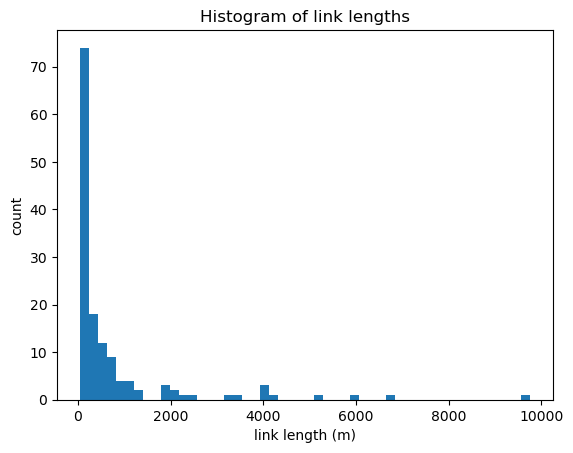

In [46]:
kanektok.compute_link_width_and_length()

# Let's look at histograms of link widths and lengths:
trash = plt.hist(kanektok.links['len_adj'], bins=50)
plt.ylabel('count')
plt.xlabel('link length (m)')
plt.title('Histogram of link lengths')

In [47]:
# Note that we provide no arguments to the compute_mesh() function.
kanektok.compute_mesh()


Computing centerline...
centerline computation is done.
Computing link widths and lengths...
link widths and lengths computed.
Generating mesh...
mesh generation is done.


In [48]:
print(kanektok.centerline)

(array([-17955831.72547651, -17955865.82635155, -17955899.92722658, ...,
       -18019054.74779946, -18019088.8486745 , -18019122.94954954]), array([8359706.17591479, 8359706.17591479, 8359747.4277615 , ...,
       8347454.3774412 , 8347413.12559449, 8347413.12559449]))


In [49]:
kanektok.to_geovectors('centerline', ftype='json')

In [50]:
kanektok.to_geovectors('mesh', ftype='json')

In [51]:
print(kanektok.paths['meshlines'])
print(kanektok.paths['meshpolys'])

C:\Users\jon20\Documents\ArcGIS\Projects\CIVIC\trollresults\kanektok_meshlines.json
C:\Users\jon20\Documents\ArcGIS\Projects\CIVIC\trollresults\kanektok_meshpolys.json


In [52]:
# grid_spacing
print('grid_spacing: {}'.format(kanektok.avg_chan_width))
# buf_halfwidth
print('buf_halfwidth: {}'.format(kanektok.max_valley_width_pixels * kanektok.pixlen * 1.1))
# smoothing by default was 0.1
print('smoothing: {}'.format(0.1))

grid_spacing: 264.73118789587346
buf_halfwidth: 1125.3288762985615
smoothing: 0.1


In [53]:
kanektok.assign_flow_directions()


Setting link directionality...
Using C:\Users\jon20\Documents\ArcGIS\Projects\CIVIC\trollresults\kanektok_fixlinks.csv to manually set flow directions.
Attempting to fix 1 cycles.
All cycles were resolved.
link directionality has been set.


C:\Users\jon20\anaconda3\envs\rivgraph_env\lib\site-packages\rivgraph\rivers\river_directionality.py:78: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  links, nodes = directional_info(links, nodes, Imask, pixlen, exit_sides,


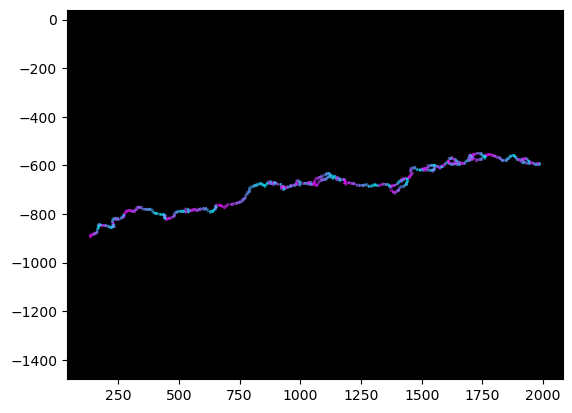

In [54]:
kanektok.plot('directions')


In [55]:
kanektok.to_geotiff('directions')


Geotiff written to C:\Users\jon20\Documents\ArcGIS\Projects\CIVIC\trollresults\kanektok_link_directions.tif.


In [56]:
kanektok.to_geovectors(export='links', ftype='shp')

C:\Users\jon20\anaconda3\envs\rivgraph_env\lib\site-packages\rivgraph\io_utils.py:262: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(path_export, driver=get_driver(path_export))
